In [4]:
!zcat /PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/combined_CRISPR_S1_L001_R2_001.fastq.gz | head -n 40

@AV242502:multiSeq_Arbab-Sherwood-labs-3:2441659124:1:10601:0458:0007 2:N:0:1
CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTCCAGCATAGCTCTTAAACGCCCTGTGAGAGCCATGCAGCCCCATATAAGAAACGATTCATTATCGCTGAATTGGGCGCATAGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGTA
+
FGGGGGEGMMMMMMMMMMLMMLMMMNMMNMMNM>NLNMKNMNMNMMNMNNNMNNNNMMNNNNNLNMNNNLMNNNMNMLMMMNMMNMMIMMMNNNNMMNNNMMMMMMNNMMNNMNMMMKCMMGMMMMMMMMLJMLLJLLLKLLLKLLKLLLLLJLLKKIL
@AV242502:multiSeq_Arbab-Sherwood-labs-3:2441659124:1:10601:0064:0063 2:N:0:1
CAAGTTGATAACGGACTAGCCTGGAAAGGACACTGTAGGATGGTCTAAACATCAGAGCAGGAGATAAGATGACTGGCTCTTGTTTGGCCTCTTCCATGAGCTCACTTTGTGATCTTCCCATATAAGAAAGCAATGCGTGAATCGTTGGACCAATACTAG
+
FGGGGGGGMMMMMMMMMMNMNMNNMNNMNNMNMMNMNMMNMNNNMMNMNNNNNNNNNNNNNNNNNMNNNMMNNNMNMNMNMNMMNNMMNMMNNNNMNNNNMNMMNMNNMMNNMKMMMMMMMMMMMMMMMMMMMLLLLLLLLLLLLLLLKLLLLLLLLLL
@AV242502:multiSeq_Arbab-Sherwood-labs-3:2441659124:1:10601:0405:0006 2:N:0:1
CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTCCAGCATAGCTCTTAAACCCAGTGATTTCCCCCGGGGTCCCCATATAAGAAATAACCGTGCCGACTTCAGTTGCTAT

# Read exploration 

In [13]:
#this is the files with the read2 .I'm sampling 100k
!zcat /PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/combined_CRISPR_S1_L001_R2_001.fastq.gz | head -n 400000 | grep -v + | grep -v @ | grep -v F   | grep -v M > reads_use.txt


gzip: stdout: Broken pipe


In [132]:
import random
import numpy as np

def simulate_reads(total_reads=1000, num_guides=100, mutated_reads_pct=0.07, no_guide_pct=0.15):
    """
    Simulates a library of DNA reads containing guide sequences.
    
    Parameters:
    - total_reads: Total number of reads to generate.
    - num_guides: Number of unique guides in the library.
    - mutated_reads_pct: Percentage of total reads (0.0 to 1.0) that should contain a mutated guide.
    - no_guide_pct: Percentage of total reads (0.0 to 1.0) that will NOT contain any guide.
    """
    if mutated_reads_pct + no_guide_pct > 1.0:
        raise ValueError("mutated_reads_pct + no_guide_pct cannot exceed 1.0 (100%).")

    BASES = ['A', 'C', 'G', 'T']
    
    # 1. Create a guide library of 100 guides, each 20 bp long
    guide_library = ["".join(random.choices(BASES, k=20)) for _ in range(num_guides)]
    
    # 2. Define the Substitution Matrix (Weights derived from the image)
    sub_matrix = {
        'A': {'C': 112, 'G': 23, 'T': 10},
        'C': {'A': 37,  'G': 13, 'T': 42},
        'G': {'A': 77,  'C': 92, 'T': 18},
        'T': {'A': 21,  'C': 3257, 'G': 13}
    }
    
    # 3. Define Position Distribution
    pos_weights = [1]*10 + [5, 5, 20, 15, 10, 15, 25, 8, 8, 12]
    pos_probs = np.array(pos_weights) / sum(pos_weights)
    positions = list(range(20))
    
    # Calculate exact counts based on percentages
    num_no_guide = int(total_reads * no_guide_pct)
    num_mutated_guides = int(total_reads * mutated_reads_pct)
    
    reads = []
    
    for i in range(total_reads):
        # Generate a random 150bp backbone
        read_seq = random.choices(BASES, k=150)
        
        # Apply ~5% background mutation noise to the read
        for j in range(150):
            if random.random() < 0.05:
                read_seq[j] = random.choice(BASES)
                
        # --- Check if this read should have NO GUIDE ---
        if i < num_no_guide:
            reads.append("".join(read_seq))
            continue
            
        # --- For the rest, process guide insertion ---
        guide = list(random.choice(guide_library))
        
        # Check if this specific guide should be MUTATED
        if i < (num_no_guide + num_mutated_guides):
            num_muts = random.randint(1, 5) # Max 5 mutations
            
            mut_positions = np.random.choice(positions, size=num_muts, replace=False, p=pos_probs)
            
            for p in mut_positions:
                orig_base = guide[p]
                if orig_base in sub_matrix and sum(sub_matrix[orig_base].values()) > 0:
                    choices = list(sub_matrix[orig_base].keys())
                    weights = list(sub_matrix[orig_base].values())
                    new_base = random.choices(choices, weights=weights, k=1)[0]
                    guide[p] = new_base
                    
        guide_str = "".join(guide)
        
        # Determine insertion offset
        base_pos = 61 # 0-indexed position 62
        
        # 10% chance to have an offset
        if random.random() < 0.10: 
            offset = int(random.gauss(mu=0, sigma=3))
            offset = max(-10, min(10, offset))
            insert_pos = base_pos + offset
        else:
            insert_pos = base_pos
            
        # Insert the guide into the read 
        read_seq[insert_pos:insert_pos+20] = list(guide_str)
        reads.append("".join(read_seq))
        
    # Shuffle the list so the 'no_guide' and 'mutated' reads are distributed randomly
    random.shuffle(reads)
    
    return guide_library, reads

# Example Usage: 
# 1000 total reads, 100 guides
# 7% of reads have specific target mutations (0.07)
# 15% of reads have no guide inserted at all (0.15)
guides, generated_reads = simulate_reads(
    total_reads=40000, 
    num_guides=100, 
    mutated_reads_pct=0.6, 
    no_guide_pct=0.20
)

print(f"Generated {len(guides)} unique guides.")
print(f"Generated {len(generated_reads)} total reads.")
print(f"Sample Read: {generated_reads[0]}")

Generated 100 unique guides.
Generated 40000 total reads.
Sample Read: CCGCGCAACTCCGTTACCGTAAGTAAAAGTTTACACATGAGTTCATGTGATTGACACTCCCATAATACAAAGTAGTACCCCGCTGCTATTCCGTGACCATAAGATTCGCGTTAATCCTTTCCCGCGGCCCACCACGGGGTGGATCTTCCC


In [145]:
reads_use = !cat reads_use.txt 
#metadata
protospacers = set(pd.read_csv("/PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/18loci_ABE8e_PerturbSeq_guide_set_rev_comp_with_ensembl.tsv", sep="\t")['spacer'])
protospacers = set( [x for x in protospacers if len(x) == 20] ) #filter out the protospacers that are not 20bp long
#simulation
# reads_use = generated_reads
# protospacers = set(guides)


In [149]:
reverse_complement = lambda x: x.translate(str.maketrans('ACGT', 'TGCA'))[::-1] #we don't need this function. But we can test it case necessary
protospacers = { reverse_complement(x) for x in protospacers}

In [150]:
len(reads_use)

100000

In [151]:
#!cat reads_use.txt | head -n 10

In [152]:
#reads_use

In [153]:
from collections import Counter

list_guides = []

for read_i in reads_use:
    #print ('-'*90)

    flank = read_i[63-12:63] #the 12k baseparits after the guide
    before =  read_i[:63-12] #region before the flank
    guide =  read_i[63:63+20] # the guide
    

    # print (flank)
    # print (flank == 'TAGCTCTTAAAC' ) 
    # print (before)
    # print (guide)
    list_guides.append(read_i) #


#TAGCTCTTAAAC

In [154]:
df_counts = pd.DataFrame.from_dict(Counter(list_guides), orient='index', columns=['count'])
df_counts = df_counts.sort_values('count', ascending=False)
df_counts['seq'] = df_counts.index
df_counts['in_metadata'] = df_counts['seq'].apply(lambda x:  x in protospacers)



In [155]:
import pandas as pd

In [156]:
#!pip install regex

In [157]:
import regex

def best_fuzzy_hits(pattern: str, protospacers, tolerance: int = 5):
    """
    For a given pattern, find all protospacer hits within tolerance (edit distance),
    sort by distance asc, and stop early if an exact match (distance 0) is found.

    Returns: list of (distance, protospacer) sorted by distance.
    """
    use = f"({pattern}){{e<={tolerance}}}"

    hits = []
    for p in protospacers:
        m = regex.search(use, p)
        if not m:
            continue

        # fuzzy_counts = (substitutions, insertions, deletions)
        dist = sum(m.fuzzy_counts)

        # exact match => early stop
        if dist == 0:
            return [(0, p)]

        hits.append((dist, p))

    hits.sort(key=lambda t: t[0])
    return hits

# Example
pattern = 'TAGCTCTTCCCC'
target = 'TAGCTCTTAAAC'
print(best_fuzzy_hits(pattern, [target], tolerance=5))  # [(4, 'TAGCTCTTAAAC')] (dist depends on edits)

# Apply to your df_counts column
# returns a Series of lists: each element is [(dist, protospacer), ...] sorted by dist
df_counts.head(100)['seq'].apply(lambda x: best_fuzzy_hits(x, protospacers, tolerance=5))

[(3, 'TAGCTCTTAAAC')]


CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAATCGAACCCTGATTCCCCGTCACCCGTGGTCACCATGGTAGGCACGGCGACTACCATCGAAAGTTGATAGGGCAGACGTTCGAATGGGTCGTCGCCGCCACGCCCATATAAGAAA    []
CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTTGGGCTGCATTCCCAAGCAACCCGACTCCGGGAAGACCCGGGCCCGGCGCGCCGGGGGCCGCTACCGGCCTCACACCGTCCACGGGCTGGGCCTCGATCAGAAGGACTTGGGCC    []
CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAATCGAACCCTGATTCCCCGTCACCCGTGGTCACCATGGTAGGCACGGCGACTACCATCGAAAGTTGATAGGGCAGACGTTCGAATGGGTCGTCGCCGCCACGGCCCATATAAGAA    []
CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAATCGAACCCTGATTCCCCGTCACCCGTGGTCACCATGGTAGGCACGGCGACTACCATCGAAAGTTGATAGGGCAGACGTTCGAATGGGTCGTCGCCGCCACCCCATATAAGAAAC    []
CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTTGGGCTGCATTCCCAAGCAACCCGACTCCGGGAAGACCCGGGCCCGGCGCGCCGGGGGCCGCTACCGGCCTCACACCGTCCACGGGCTGGGCCTCGATCAGCCCATATAAGAAA    []
                                                                                                                                                                   ..
CAAG

In [158]:
# import regex

# tolerance = 5  # keep yours
# seq_col = "seq"  # change if needed

# def color_match(seq: str, start: int, end: int, label: str = "") -> str:
#     RESET = "\033[0m"
#     DIM   = "\033[2m"
#     BOLD  = "\033[1m"

#     BG    = "\033[48;5;45m"   # cyan-ish background
#     FG    = "\033[38;5;16m"   # near-black foreground
#     POS   = "\033[38;5;214m"  # orange for pointer line

#     left = seq[:start]
#     mid  = seq[start:end]
#     right= seq[end:]

#     pointer = f"{POS}{' ' * start}{'^' * max(1, end-start)}{RESET}"

#     out = []
#     if label:
#         out.append(f"{BOLD}{label}{RESET}")
#     out.append(f"{DIM}{left}{RESET}{BG}{FG}{mid}{RESET}{DIM}{right}{RESET}")
#     out.append(pointer)
#     return "\n".join(out)

# def best_fuzzy_match(pattern: str, protospacers, tolerance: int):
#     best = None  # (total_edits, start, protospacer, match_obj)
#     for p in protospacers:
#         # escape in case protospacer contains regex metacharacters
#         use = f"({regex.escape(p)}){{e<={tolerance}}}"
#         m = regex.search(use, pattern, flags=regex.BESTMATCH)
#         if not m:
#             continue
#         subs, ins, dels = m.fuzzy_counts
#         total = subs + ins + dels
#         s, e = m.span()
#         cand = (total, s, p, m)
#         if best is None or cand[:2] < best[:2]:
#             best = cand
#     return best

# # ---- run for all rows ----
# for i, row in df_counts.head(1000).reset_index(drop=True).iterrows():
#     pattern = row[seq_col]

#     best = best_fuzzy_match(pattern, protospacers, tolerance)

#     header = f"Row {i}"
#     if best is None:
#         print(f"\n{header}: No fuzzy matches within tolerance={tolerance}")
#         continue

#     total, s, p, m = best
#     subs, ins, dels = m.fuzzy_counts
#     e = m.span()[1]

#     print("\n" + "=" * 80)
#     print(f"{header} | best protospacer={p} | span={s}:{e} | edits={total} (subs={subs}, ins={ins}, dels={dels})")
#     print(color_match(pattern, s, e, label="Pattern (best match highlighted)"))

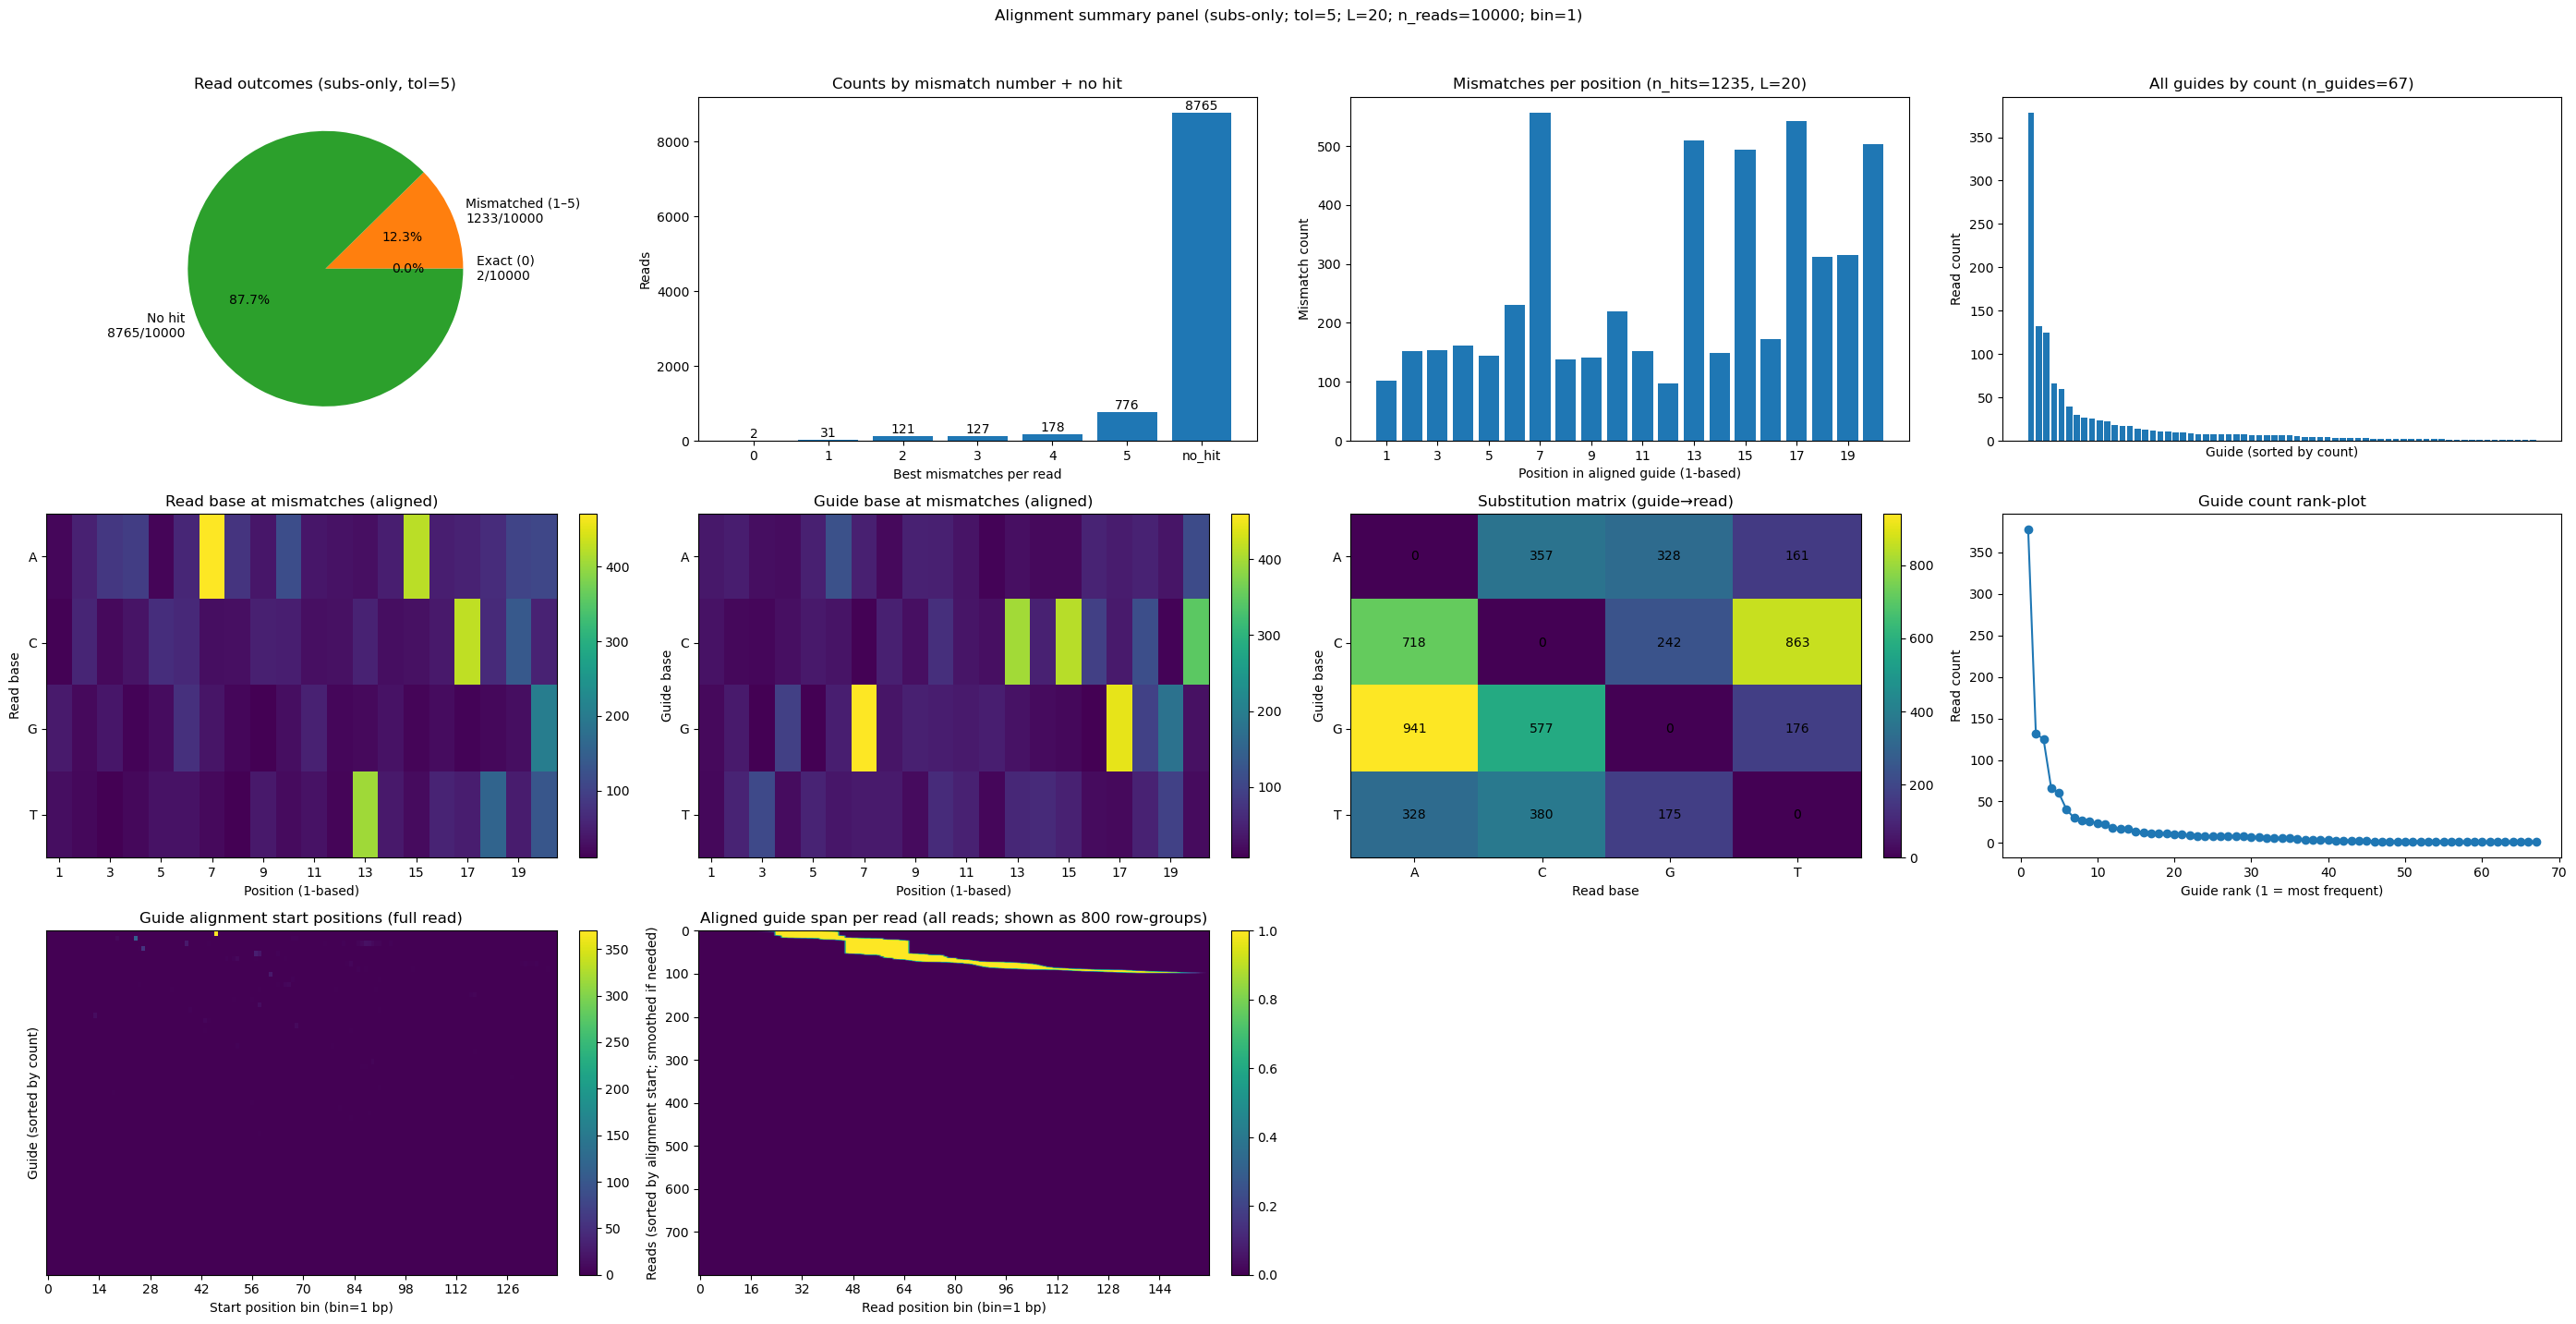

,category,count,fraction
0,0 mismatches,2,0.0002
1,1 mismatches,31,0.0031
2,2 mismatches,121,0.0121
3,3 mismatches,127,0.0127
4,4 mismatches,178,0.0178
5,5 mismatches,776,0.0776
6,no hit,8765,0.8765


,df_index,best_guide,start,end,mismatches,mismatch_positions_1based,mismatch_pairs(proto>read),aligned_read_window,read_len
0,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
1,CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
2,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
3,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
4,CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
...,...,...,...,...,...,...,...,...,...
9995,CAAGTTGATAACGGACTAGCCATTTATTCTAACCACCTGCTTCCAA...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
9996,CAAGTTGATAACGGACTAGCCCTTAGAGCCAATCCTTATCCCGAAG...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
9997,CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTC...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159
9998,CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTC...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,159


,assigned_count_by_guide
CAGCATGGCTCTCACAGGGC,378
CCAACATGGTGAAACCCCGC,132
CCTGTAGTCCCAGCTACTTA,125
AACATGGTGAAACCCCGCCT,66
TTTGAAAATCACCCCACTGC,60
...,...
TATATACGCAAATACTGCTC,1
CTGCCACTGTATTCAGCCTG,1
GGGGACTATGGAAGGTTTCT,1
GTTTGATTCCCTGTCCTCAC,1


In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# Inputs you already have:
#   df_counts  (must contain seq_col, default "seq")
#   protospacers (original guide sequences)
# =============================

# -----------------------------
# (Optional) clip for matching ONLY
# -----------------------------
TARGET_LEN = 20  # set None to disable clipping
protospacers_orig = [str(p) for p in protospacers]

if TARGET_LEN is None:
    protospacers_match = protospacers_orig
else:
    protospacers_match = [p[:TARGET_LEN] for p in protospacers_orig]
    protospacers_match = [p for p in protospacers_match if len(p) == TARGET_LEN]
    seen = set()
    protospacers_match = [p for p in protospacers_match if not (p in seen or seen.add(p))]


# -----------------------------
# Subs-only "best hit anywhere in read" (Hamming scan)
# -----------------------------
def best_subs_only_hit_in_read(read: str, proto: str, tolerance: int = 5):
    L = len(proto)
    if L == 0 or L > len(read):
        return None

    best = None  # (mism, start, window)
    for s in range(0, len(read) - L + 1):
        window = read[s:s + L]
        mism = sum(a != b for a, b in zip(window, proto))
        if mism <= tolerance:
            cand = (mism, s, window)
            if best is None or cand[:2] < best[:2]:
                best = cand
                if mism == 0:
                    break

    if best is None:
        return None

    mism, s, window = best
    return {
        "dist": mism, "subs": mism, "ins": 0, "dels": 0,
        "proto": proto, "start": s, "end": s + L, "window": window
    }


def best_hit_info_in_read(read: str, protospacers, tolerance: int = 5):
    best = None  # (dist, start, hit)
    for p in protospacers:
        hit = best_subs_only_hit_in_read(read, p, tolerance=tolerance)
        if hit is None:
            continue
        cand = (hit["dist"], hit["start"], hit)
        if best is None or cand[:2] < best[:2]:
            best = cand
    return None if best is None else best[2]


# -----------------------------
# Helper: downsample rows for display (keeps ALL reads, smoother if huge)
# -----------------------------
def downsample_rows_mean(mat: np.ndarray, target_rows: int):
    """
    Downsample rows by averaging contiguous blocks.
    Keeps the x-axis untouched (positions), reduces y-axis for plotting.
    Returns (downsampled_mat, row_group_sizes)
    """
    n_rows = mat.shape[0]
    if n_rows <= target_rows or target_rows <= 0:
        return mat, np.ones(n_rows, dtype=int)

    edges = np.linspace(0, n_rows, target_rows + 1).astype(int)
    out = np.zeros((target_rows, mat.shape[1]), dtype=float)
    sizes = np.zeros(target_rows, dtype=int)

    for i in range(target_rows):
        a, b = edges[i], edges[i + 1]
        if b <= a:
            b = min(n_rows, a + 1)
        block = mat[a:b]
        out[i] = block.mean(axis=0)
        sizes[i] = b - a

    return out, sizes


# -----------------------------
# Main: mismatch table + SINGLE FIGURE PANEL
# - ALL other plots unchanged
# - read-vs-position heatmap now includes ALL reads:
#     * sort reads by alignment start
#     * optionally "smooth" (row-downsample) for display only
# -----------------------------
def mismatch_table_and_panel_figure(
    df_counts,
    protospacers_match,
    seq_col="seq",
    tolerance=5,
    n_rows=None,
    pos_bin_size=1,            # bins for start-position heatmaps and read span heatmap
    read_heatmap_max_rows=800, # display cap; all reads included via smoothing/downsampling
):
    df = df_counts.copy()
    if n_rows is not None:
        df = df.head(n_rows)

    reads = df[seq_col].astype(str).values
    total = len(reads)

    lengths = {len(p) for p in protospacers_match}
    if len(lengths) != 1:
        raise ValueError(f"protospacers_match must all be same length; got {sorted(lengths)}")
    L = next(iter(lengths))

    bases = ["A", "C", "G", "T"]
    b2i = {b: i for i, b in enumerate(bases)}

    dist_counts = {k: 0 for k in range(tolerance + 1)}
    no_hit = 0

    mismatch_pos_counts = np.zeros(L, dtype=int)
    read_base_at_mismatch = np.zeros((4, L), dtype=int)
    proto_base_at_mismatch = np.zeros((4, L), dtype=int)
    sub_matrix = np.zeros((4, 4), dtype=int)

    guide_counts = {}

    rows = []
    per_read_best_dist = []
    per_read_best_start = []
    per_read_best_end = []
    per_read_best_guide = []

    for idx, read in zip(df.index, reads):
        hit = best_hit_info_in_read(read, protospacers_match, tolerance=tolerance)

        if hit is None:
            no_hit += 1
            per_read_best_dist.append(pd.NA)
            per_read_best_start.append(pd.NA)
            per_read_best_end.append(pd.NA)
            per_read_best_guide.append(pd.NA)
            rows.append({
                "df_index": idx,
                "best_guide": pd.NA,
                "start": pd.NA,
                "end": pd.NA,
                "mismatches": pd.NA,
                "mismatch_positions_1based": pd.NA,
                "mismatch_pairs(proto>read)": pd.NA,
                "aligned_read_window": pd.NA,
                "read_len": len(read),
            })
            continue

        d = hit["dist"]
        if d <= tolerance:
            dist_counts[d] += 1
        else:
            no_hit += 1
            per_read_best_dist.append(pd.NA)
            per_read_best_start.append(pd.NA)
            per_read_best_end.append(pd.NA)
            per_read_best_guide.append(pd.NA)
            rows.append({
                "df_index": idx,
                "best_guide": pd.NA,
                "start": pd.NA,
                "end": pd.NA,
                "mismatches": pd.NA,
                "mismatch_positions_1based": pd.NA,
                "mismatch_pairs(proto>read)": pd.NA,
                "aligned_read_window": pd.NA,
                "read_len": len(read),
            })
            continue

        proto = hit["proto"]
        window = hit["window"]
        start = int(hit["start"])
        end = int(hit["end"])

        guide_counts[proto] = guide_counts.get(proto, 0) + 1

        per_read_best_dist.append(d)
        per_read_best_start.append(start)
        per_read_best_end.append(end)
        per_read_best_guide.append(proto)

        mismatch_positions = []
        mismatch_pairs = []

        for j, (rb, pb) in enumerate(zip(window, proto)):
            if rb != pb:
                mismatch_positions.append(j + 1)
                mismatch_pairs.append(f"{pb}>{rb}")

                mismatch_pos_counts[j] += 1
                if rb in b2i:
                    read_base_at_mismatch[b2i[rb], j] += 1
                if pb in b2i:
                    proto_base_at_mismatch[b2i[pb], j] += 1
                if rb in b2i and pb in b2i:
                    sub_matrix[b2i[pb], b2i[rb]] += 1

        rows.append({
            "df_index": idx,
            "best_guide": proto,
            "start": start,
            "end": end,
            "mismatches": d,
            "mismatch_positions_1based": mismatch_positions if mismatch_positions else [],
            "mismatch_pairs(proto>read)": mismatch_pairs if mismatch_pairs else [],
            "aligned_read_window": window,
            "read_len": len(read),
        })

    mismatch_table = pd.DataFrame(rows)

    exact = dist_counts[0]
    mismatched_any = total - exact - no_hit
    used_hits = total - no_hit

    summary_df = pd.DataFrame(
        [{"category": f"{k} mismatches", "count": dist_counts[k], "fraction": dist_counts[k] / total}
         for k in range(tolerance + 1)]
        + [{"category": "no hit", "count": no_hit, "fraction": no_hit / total}]
    )

    guide_counts_s = pd.Series(guide_counts).sort_values(ascending=False)

    # -----------------------------
    # Heatmap: guides x read-start bins (sorted by guide count)
    # -----------------------------
    max_read_len = max((len(r) for r in reads), default=0)
    max_start = max(0, max_read_len - L)
    n_bins = (max_start // pos_bin_size) + 1

    guide_list = list(guide_counts_s.index)
    guide_to_row = {g: i for i, g in enumerate(guide_list)}
    align_heat_guides = np.zeros((len(guide_list), n_bins), dtype=int)

    # per-read starts/ends
    starts = pd.Series(per_read_best_start, index=df.index, dtype="Int64")
    ends = pd.Series(per_read_best_end, index=df.index, dtype="Int64")

    for _, r in mismatch_table.dropna(subset=["best_guide", "start"]).iterrows():
        g = r["best_guide"]
        s = int(r["start"])
        b = min(n_bins - 1, s // pos_bin_size)
        align_heat_guides[guide_to_row[g], b] += 1

    # -----------------------------
    # NEW: Read-vs-position heatmap INCLUDING ALL READS
    #   - build span mask for every read (row)
    #   - sort rows by start position (aligned position)
    #   - downsample rows by averaging blocks for display if very large
    # -----------------------------
    # order indices by start (NaNs at bottom)
    order = pd.DataFrame({"idx": df.index, "start": starts.values})
    order["start_filled"] = order["start"].fillna(10**12)  # push no-hit to bottom
    order = order.sort_values(["start_filled", "idx"])
    ordered_idx = order["idx"].values

    # x-axis bins based on max read length in this df
    n_pos_bins = (max_read_len // pos_bin_size) + 1
    read_span_heat = np.zeros((len(df), n_pos_bins), dtype=float)

    # fill span mask for all reads
    for row_i, idx in enumerate(ordered_idx):
        s = starts.loc[idx]
        e = ends.loc[idx]
        if pd.isna(s) or pd.isna(e):
            continue
        s = int(s); e = int(e)
        b0 = max(0, s // pos_bin_size)
        b1 = min(n_pos_bins, max(0, (e - 1) // pos_bin_size + 1))
        if b1 > b0:
            read_span_heat[row_i, b0:b1] = 1.0

    # downsample rows for plotting only (still represents ALL reads)
    read_span_heat_plot, row_group_sizes = downsample_rows_mean(read_span_heat, read_heatmap_max_rows)

    # -----------------------------
    # SINGLE FIGURE PANEL (3x4) — same plots as before, plus improved read heatmap
    # -----------------------------
    fig, axes = plt.subplots(3, 4, figsize=(28, 14))

    # (1) PIE outcomes
    ax = axes[0, 0]
    pie_sizes = [exact, mismatched_any, no_hit]
    pie_labels = [
        f"Exact (0)\n{exact}/{total}",
        f"Mismatched (1–{tolerance})\n{mismatched_any}/{total}",
        f"No hit\n{no_hit}/{total}",
    ]
    ax.pie(pie_sizes, labels=pie_labels, autopct=lambda p: f"{p:.1f}%")
    ax.set_title(f"Read outcomes (subs-only, tol={tolerance})")

    # (2) BAR mismatch distribution
    ax = axes[0, 1]
    x_labels = [str(k) for k in range(tolerance + 1)] + ["no_hit"]
    y = [dist_counts[k] for k in range(tolerance + 1)] + [no_hit]
    x = np.arange(len(x_labels))
    ax.bar(x, y)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Best mismatches per read")
    ax.set_ylabel("Reads")
    ax.set_title("Counts by mismatch number + no hit")
    for xi, yi in zip(x, y):
        ax.text(xi, yi, str(yi), ha="center", va="bottom")

    # (3) BAR mismatch-by-position (aligned to guide)
    ax = axes[0, 2]
    pos_x = np.arange(1, L + 1)
    ax.bar(pos_x, mismatch_pos_counts)
    ax.set_xlabel("Position in aligned guide (1-based)")
    ax.set_ylabel("Mismatch count")
    ax.set_title(f"Mismatches per position (n_hits={used_hits}, L={L})")
    step = max(1, L // 10)
    xt = np.arange(1, L + 1, step)
    ax.set_xticks(xt)
    ax.set_xticklabels([str(v) for v in xt])

    # (4) ALL-guides bar plot (sorted)
    ax = axes[0, 3]
    if len(guide_counts_s) == 0:
        ax.text(0.5, 0.5, "No guide hits", ha="center", va="center")
        ax.set_axis_off()
    else:
        ax.bar(np.arange(len(guide_counts_s)), guide_counts_s.values)
        ax.set_xlabel("Guide (sorted by count)")
        ax.set_ylabel("Read count")
        ax.set_title(f"All guides by count (n_guides={len(guide_counts_s)})")
        ax.set_xticks([])

    # (5) Heatmap read base at mismatches
    ax = axes[1, 0]
    im = ax.imshow(read_base_at_mismatch, aspect="auto")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xticks(np.arange(0, L, step))
    ax.set_xticklabels([str(v) for v in range(1, L + 1, step)])
    ax.set_xlabel("Position (1-based)")
    ax.set_ylabel("Read base")
    ax.set_title("Read base at mismatches (aligned)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (6) Heatmap guide base at mismatches
    ax = axes[1, 1]
    im = ax.imshow(proto_base_at_mismatch, aspect="auto")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xticks(np.arange(0, L, step))
    ax.set_xticklabels([str(v) for v in range(1, L + 1, step)])
    ax.set_xlabel("Position (1-based)")
    ax.set_ylabel("Guide base")
    ax.set_title("Guide base at mismatches (aligned)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (7) Substitution matrix
    ax = axes[1, 2]
    im = ax.imshow(sub_matrix, aspect="auto")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(bases)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xlabel("Read base")
    ax.set_ylabel("Guide base")
    ax.set_title("Substitution matrix (guide→read)")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(sub_matrix[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (8) Guide rank plot
    ax = axes[1, 3]
    if len(guide_counts_s) == 0:
        ax.text(0.5, 0.5, "No guide hits", ha="center", va="center")
        ax.set_axis_off()
    else:
        ranks = np.arange(1, len(guide_counts_s) + 1)
        ax.plot(ranks, guide_counts_s.values, marker="o", linestyle="-")
        ax.set_xlabel("Guide rank (1 = most frequent)")
        ax.set_ylabel("Read count")
        ax.set_title("Guide count rank-plot")

    # (9) Heatmap: guides x read-start bins (full read)
    ax = axes[2, 0]
    if align_heat_guides.size == 0 or align_heat_guides.sum() == 0:
        ax.text(0.5, 0.5, "No alignments to plot", ha="center", va="center")
        ax.set_axis_off()
    else:
        im = ax.imshow(align_heat_guides, aspect="auto")
        ax.set_ylabel("Guide (sorted by count)")
        ax.set_xlabel(f"Start position bin (bin={pos_bin_size} bp)")
        ax.set_title("Guide alignment start positions (full read)")
        ax.set_yticks([])
        tick_step = max(1, n_bins // 10)
        xticks = np.arange(0, n_bins, tick_step)
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(t * pos_bin_size)) for t in xticks])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (10) Heatmap: reads x read-position (full read), sorted by start, smoothed if huge
    ax = axes[2, 1]
    if read_span_heat_plot.size == 0 or np.nansum(read_span_heat_plot) == 0:
        ax.text(0.5, 0.5, "No read spans to plot", ha="center", va="center")
        ax.set_axis_off()
    else:
        im = ax.imshow(read_span_heat_plot, aspect="auto")
        ax.set_xlabel(f"Read position bin (bin={pos_bin_size} bp)")
        ax.set_ylabel("Reads (sorted by alignment start; smoothed if needed)")
        ax.set_title(f"Aligned guide span per read (all reads; shown as {read_span_heat_plot.shape[0]} row-groups)")
        # x ticks in bp
        tick_step = max(1, read_span_heat_plot.shape[1] // 10)
        xticks = np.arange(0, read_span_heat_plot.shape[1], tick_step)
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(t * pos_bin_size)) for t in xticks])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[2, 2].set_axis_off()
    axes[2, 3].set_axis_off()

    fig.suptitle(
        f"Alignment summary panel (subs-only; tol={tolerance}; L={L}; n_reads={total}; bin={pos_bin_size})",
        y=1.02
    )
    fig.tight_layout()
    plt.show()

    per_read_best_dist_s = pd.Series(per_read_best_dist, index=df.index, dtype="Int64")
    per_read_best_start_s = pd.Series(per_read_best_start, index=df.index, dtype="Int64")
    per_read_best_guide_s = pd.Series(per_read_best_guide, index=df.index, dtype="string")

    return summary_df, mismatch_table, per_read_best_dist_s, per_read_best_start_s, per_read_best_guide_s, guide_counts_s


# -----------------------------
# RUN
# -----------------------------
summary_df, mismatch_table, per_read_best_dist, per_read_best_start, per_read_best_guide, guide_counts_s = (
    mismatch_table_and_panel_figure(
        df_counts.head(10000),   # or df_counts (you said you'll pre-filter)
        protospacers_match,
        seq_col="seq",
        tolerance=5,
        pos_bin_size=1,          # increase (5/10) if reads are long
        read_heatmap_max_rows=800,  # smaller -> more smoothing, faster to render
    )
)


display(summary_df)
display(mismatch_table)
display(guide_counts_s.rename("assigned_count_by_guide").to_frame())

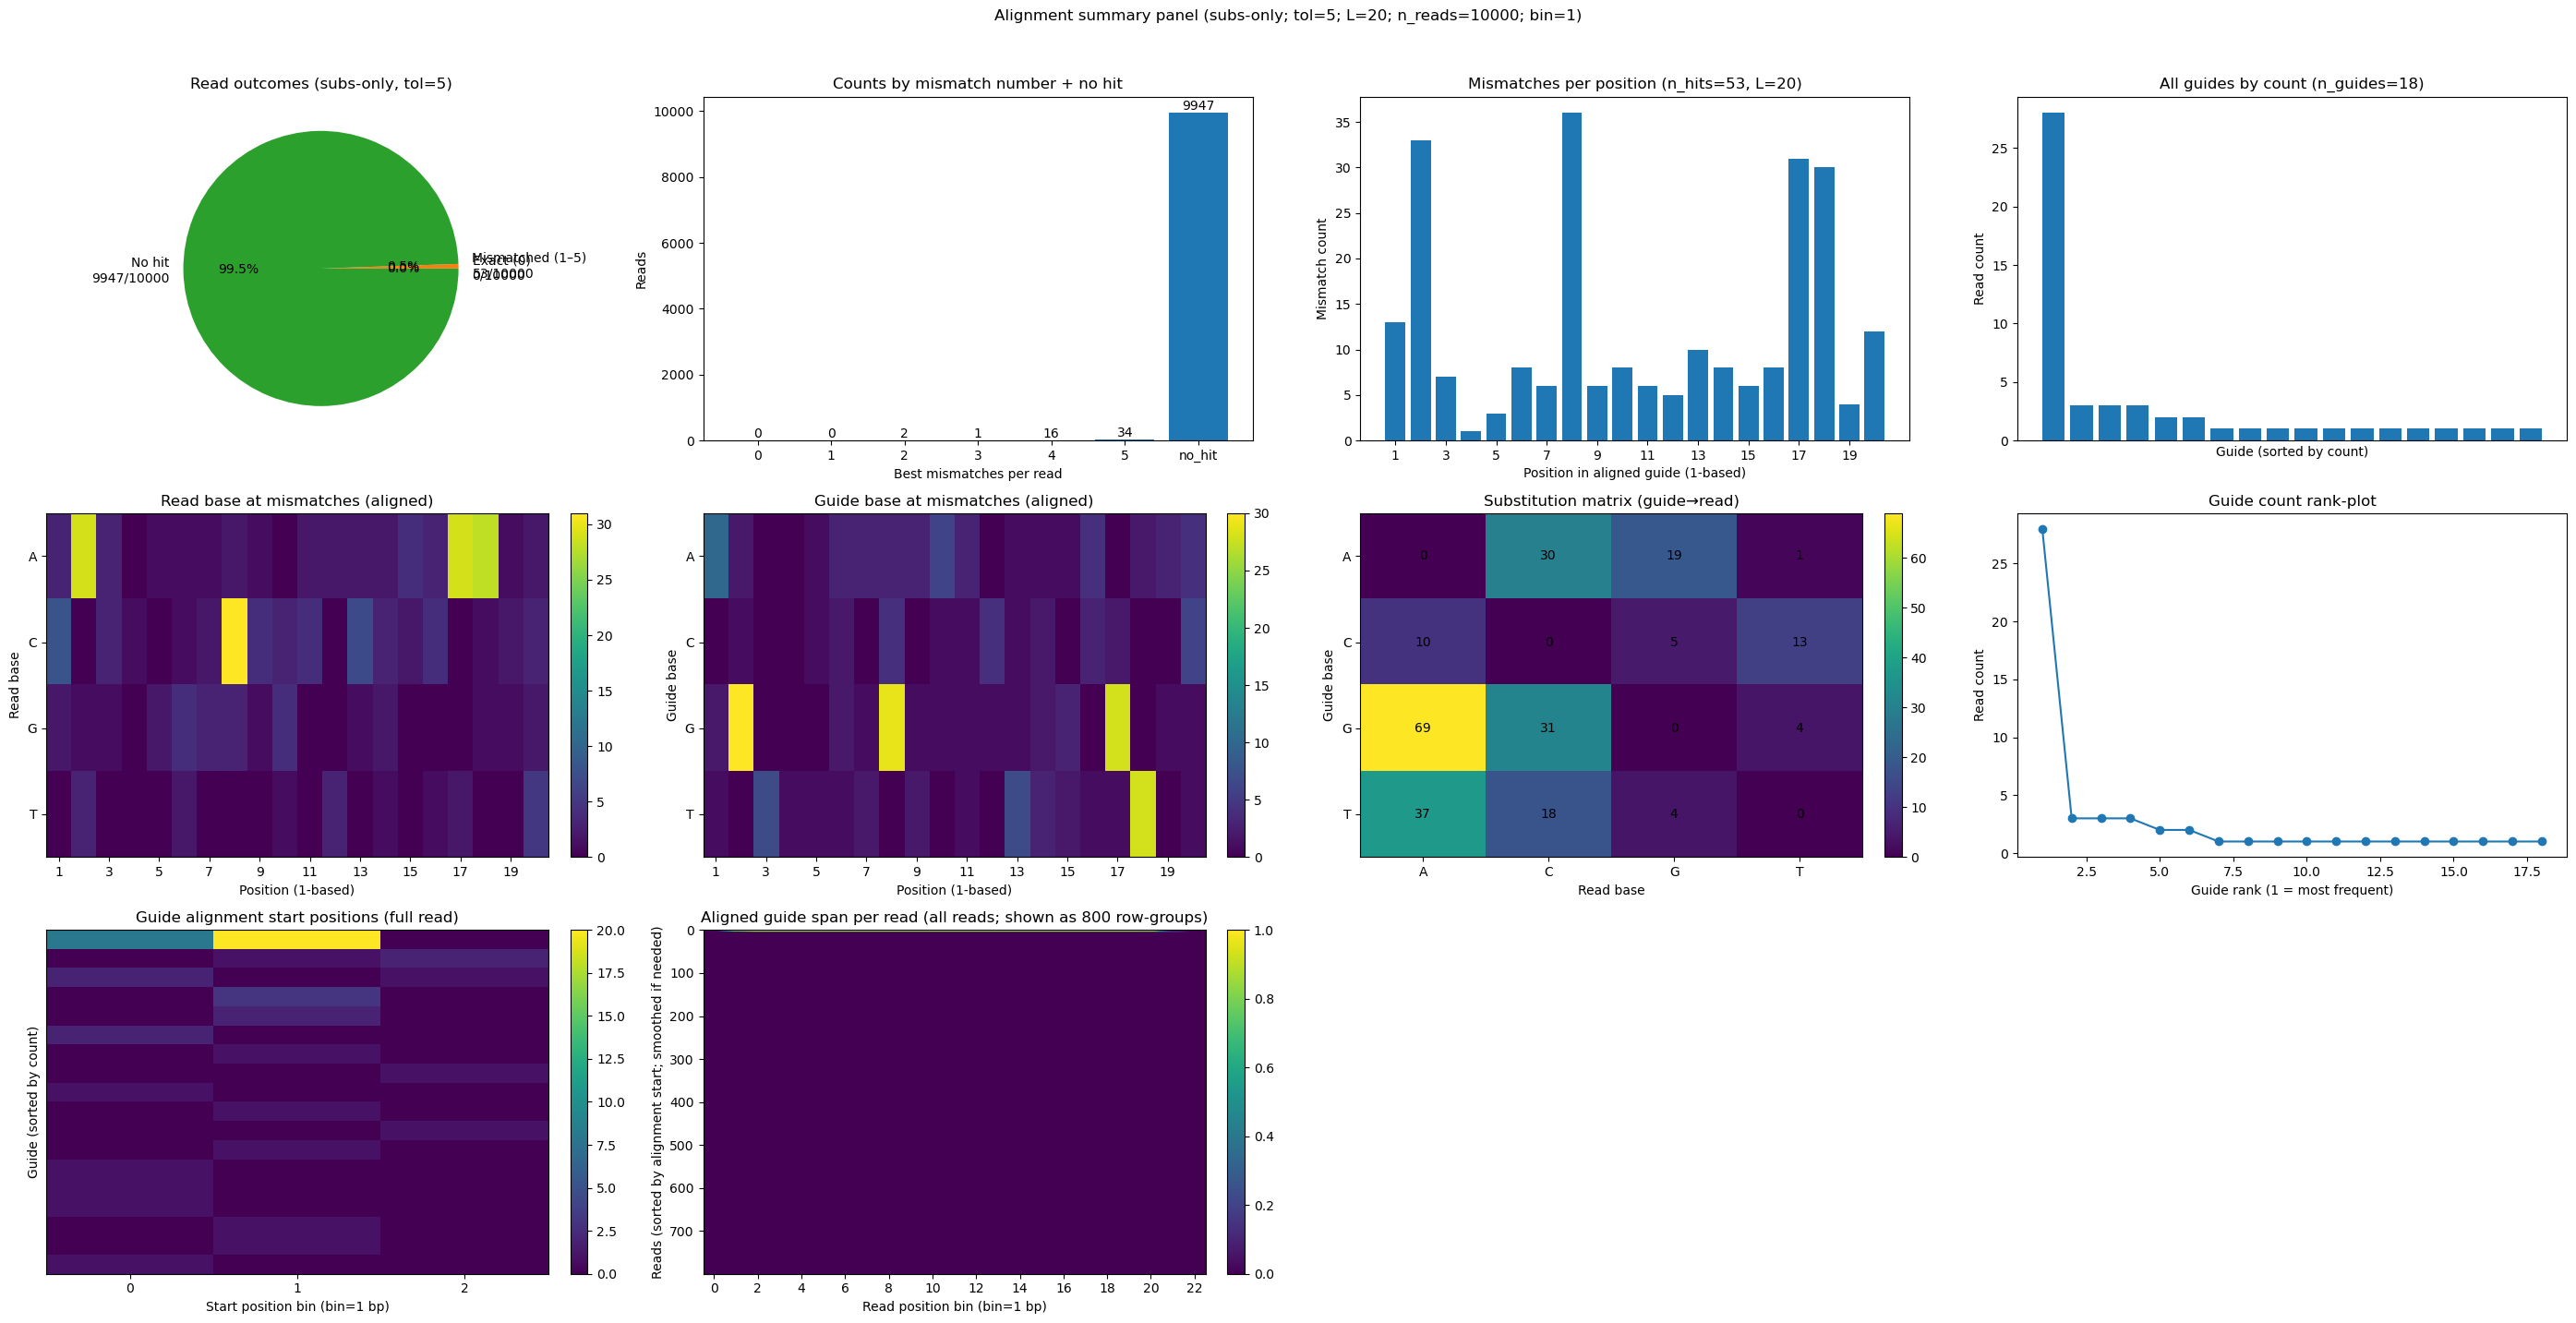

,category,count,fraction
0,0 mismatches,0,0.0000
1,1 mismatches,0,0.0000
2,2 mismatches,2,0.0002
3,3 mismatches,1,0.0001
4,4 mismatches,16,0.0016
5,5 mismatches,34,0.0034
6,no hit,9947,0.9947


,df_index,best_guide,start,end,mismatches,mismatch_positions_1based,mismatch_pairs(proto>read),aligned_read_window,read_len
0,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
1,CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
2,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
3,CAAGTTGATAACGGACTAGCCGTTTCTCAGGCTCCCTCTCCGGAAT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
4,CAAGTTGATAACGGACTAGCCTTAGATGGAGTTTACCACCCGCTTT...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
...,...,...,...,...,...,...,...,...,...
9995,CAAGTTGATAACGGACTAGCCATTTATTCTAACCACCTGCTTCCAA...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
9996,CAAGTTGATAACGGACTAGCCCTTAGAGCCAATCCTTATCCCGAAG...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
9997,CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTC...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22
9998,CAAGTTGATAACGGACTAGCCTTATTTAAACTTGCTATGCTGTTTC...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22


,assigned_count_by_guide
AGATCACGCCACTGCAGTCC,28
GGTCTCACTATGTTGCCCAG,3
GTCTCACTATGTTGCCCAGG,3
TTTGAAAATCACCCCACTGC,3
GATTGCACCAGTGCACTCCA,2
TACAGGTGTGAGCCACCAAA,2
GCACACGCTACAAGGAAACA,1
TGAGTATTTATCTGAAACAT,1
CACACCACTGCACTCCAGCC,1
AGTTTGCAGTGGGGTGATTT,1


In [163]:
df_counts['seqs_specific_region'] = df_counts['seq'].apply(lambda x: x[62:63+21])  # Extract the specific region from each sequence
# -----------------------------
# RUN
# -----------------------------
summary_df, mismatch_table, per_read_best_dist, per_read_best_start, per_read_best_guide, guide_counts_s = (
    mismatch_table_and_panel_figure(
        df_counts.head(10000),   # or df_counts (you said you'll pre-filter)
        protospacers_match,
        seq_col="seqs_specific_region",
        tolerance=5,
        pos_bin_size=1,          # increase (5/10) if reads are long
        read_heatmap_max_rows=800,  # smaller -> more smoothing, faster to render
    )
)


display(summary_df)
display(mismatch_table)
display(guide_counts_s.rename("assigned_count_by_guide").to_frame())

In [ ]:
%%bash
!cut -f 2 "/PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/18loci_ABE8e_PerturbSeq_guide_set_rev_comp_with_ensembl.tsv" > guides.txt
m=5
while read -r g; do
 n=$(agrep -"$m" "$g" reads_use.txt | wc -l)
 printf "%s\t%s\n" "$g" "$n"
done < guides.txt > guide_counts.tsv

bash: line 1: !cut: command not found


Retrieving notices: ...working... failed
^C
Traceback (most recent call last):
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/exceptions.py", line 1124, in __call__
    return func(*args, **kwargs)
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/cli/main.py", line 69, in main_subshell
    exit_code = do_call(args, p)
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/cli/conda_argparse.py", line 91, in do_call
    return getattr(module, func_name)(args, parser)
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/notices/core.py", line 98, in wrapper
    channel_notice_set = retrieve_notices(
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/notices/core.py", line 39, in retrieve_notices
    channel_notice_responses = fetch.get_notice_responses(channel_name_urls, silent=silent)
  File "/PHShome/lf588/miniconda3/lib/python3.9/site-packages/conda/notices/fetch.py", line 36, in get_notice_responses


In [ ]:
import re
df_counts['seq'].apply(lambda x : len(re.findall('A',x)) ).sort_values()

<MMNNLNNLDNMMNMJKKLK     0
CCCGGCGGGGGGCGGTCGCC     0
MNNNMMNMKNN,LIKHM:NN     0
NNLNNNNNNNLNNNNNNMNN     0
LNMHMJNMMJMKMNMMMNMN     0
                        ..
AAAAAAAAAAAGAAAGAAAA    18
AAAAAAAAAAAAAAAAAGAA    19
AAAAAAAAAAAAAAAAAATA    19
AAAAAAAAAAAAAAAAAAAG    19
AAAAAAAAAAAAAAAAAAAA    20
Name: seq, Length: 31487, dtype: int64

In [ ]:
df_counts.groupby(['in_metadata']).count()['count']

in_metadata
False    30769
True       718
Name: count, dtype: int64

In [ ]:
for x in reads:
    for p in protospacers:
        if p in x:
            print(x.find(p))
            print (p)
            print (x[63:63+20])
            print ('------------------------------')


